In [10]:
import time
import sys
import os
import argparse
import io
import copy
from datetime import datetime
import numpy as np
import awkward
#from gnn_encoder import GNNEncoder, collate_fn_gnn
#from gnn_trafo_helper import train_model, evaluate_model, normalize_x, normalize_y, normalize_time, denormalize_x, denormalize_y, get_img_from_matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool

In [11]:
DATA_PATH = "./data_pq/"  # path to the data

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")


The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

In [12]:
# define a helper function to normalize the data
def Normalize(data):
    mean = awkward.mean(data)
    std = awkward.std(data)
    # prevent division by zero
    if std == 0:
        std = 1.0
    return (data - mean) / std, mean, std


# Normalize data and labels
times = train_dataset["data"][:, 0:1, :]
norm_times, t_mean, t_std = Normalize(times)

x = train_dataset["data"][:, 1:2, :]
norm_x, dx_mean, dx_std = Normalize(x)

y = train_dataset["data"][:, 2:3, :]
norm_y, dy_mean, dy_std = Normalize(y)

# Concatenate the normalized data back together
train_dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)

# Compute label normalization metrics
x_mean = awkward.mean(train_dataset["xpos"])
x_std = awkward.std(train_dataset["xpos"])
y_mean = awkward.mean(train_dataset["ypos"])
y_std = awkward.std(train_dataset["ypos"])

# Normalize labels in-place
train_dataset["xpos"] = (train_dataset["xpos"] - x_mean) / x_std
train_dataset["ypos"] = (train_dataset["ypos"] - y_mean) / y_std


In [13]:
for dataset in [val_dataset, test_dataset]:
    # Normalize the data
    times = dataset["data"][:, 0:1, :]
    norm_times, t_mean, t_std = Normalize(times)

    x = dataset["data"][:, 1:2, :]
    norm_x, dx_mean, dx_std = Normalize(x)

    y = dataset["data"][:, 2:3, :]
    norm_y, dy_mean, dy_std = Normalize(y)

    # Concatenate the normalized data back together
    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)

    # Normalize labels (this can be done in-place), e.g. by
    dataset["xpos"] = (dataset["xpos"] - x_mean) / x_std
    dataset["ypos"] = (dataset["ypos"] - y_mean) / y_std

In [14]:
def collate_fn_gnn(batch):
    """
    This function takes the Awkward arrays, converts them to PyTorch tensors,
    and then creates a PyTorch Geometric Data object for each event in the batch.
    """
    data_list = []
    labels = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        # for training a GNN, we need the graph notes, i.e., the individual hits, as the first dimension,
        # so we need to transpose to get (n_hits, n_features)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        # PyTorch Geometric needs the data in a specific format
        # we need to create a PyTorch Geometric Data object for each event
        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor
    packed_data = Batch.from_data_list(data_list) # convert the list of Data objects to a single Batch object
    return packed_data, labels

In [15]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

In [16]:
class GNNEncoder(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, out_channels=2, k=16, num_layers=3):
        super(GNNEncoder, self).__init__()
        self.k = k
        self.layer_list = nn.ModuleList()
        
        # First EdgeConv layer
        self.layer_list.append(
            DynamicEdgeConv(
                nn.Sequential(
                    nn.Linear(2 * in_channels, hidden_channels),
                    nn.ReLU(),
                    nn.Linear(hidden_channels, hidden_channels),
                    nn.ReLU()
                ),
                aggr='mean', k=k
            )
        )
        
        # Additional layers (if num_layers > 1)
        for _ in range(num_layers - 1):
            self.layer_list.append(
                DynamicEdgeConv(
                    nn.Sequential(
                        nn.Linear(2 * hidden_channels, hidden_channels),
                        nn.ReLU(),
                        nn.Linear(hidden_channels, hidden_channels),
                        nn.ReLU()
                    ),
                    aggr='mean', k=k
                )
            )
            
        # Final MLP layer to map the output dimension to the number of labels you want to predict
        self.final_mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch

        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)

        # To combine all node features into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, hidden_channels)

        # map the output dimension to the number of labels you want to predict
        x = self.final_mlp(x)

        return x


In [21]:
def train_model(model, train_loader, val_loader, optimizer, epochs=20, device='cpu', patience=10, model_name=None):
    """
    Trains the GNN model and evaluates on the validation set after each epoch.
    Returns lists of the average training and validation losses per epoch.
    """
    model = model.to(device)
    train_losses = []
    val_losses = []

    #finding best model
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    print(f"Starting training for {epochs} epochs on {device}...")
    for epoch in range(epochs):

        start = time.time()

        # --- Training Phase ---
        model.train()
        total_train_loss = 0
        for data, labels in train_loader:
            data = data.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            out = model(data)
            
            # Using Mean Squared Error as the loss function for coordinate regression
            loss = F.mse_loss(out, labels)
            loss.backward()
            optimizer.step()
            
            # Accumulate loss (multiply by batch size which is data.num_graphs in PyG)
            total_train_loss += loss.item() * data.num_graphs
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)
        
        # --- Validation Phase ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for data, labels in val_loader:
                data = data.to(device)
                labels = labels.to(device)
                
                out = model(data)
                loss = F.mse_loss(out, labels)
                total_val_loss += loss.item() * data.num_graphs
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)
        
        epoch_time = time.time() - start
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f} seconds")
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
            
    return train_losses, val_losses, best_model
    
def plot_train(train_losses, val_losses):
    """
    Plots the training and validation loss curves over the epochs.
    """
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)
    
    plt.plot(epochs, train_losses, marker='o', label='Training Loss', color='blue', linewidth=2)
    plt.plot(epochs, val_losses, marker='o', label='Validation Loss', color='orange', linewidth=2)
    
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE) Loss', fontsize=12)
    plt.title('Training and Validation Loss Curve', fontsize=14)
    plt.xticks(epochs)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Starting training for 100 epochs on cpu...
Epoch 01/100 | Train Loss: 0.5672 | Val Loss: 0.2758 | Time: 13.05 seconds
Epoch 02/100 | Train Loss: 0.2156 | Val Loss: 0.1870 | Time: 12.11 seconds
Epoch 03/100 | Train Loss: 0.1808 | Val Loss: 0.1794 | Time: 12.57 seconds
Epoch 04/100 | Train Loss: 0.1659 | Val Loss: 0.1634 | Time: 12.04 seconds
Epoch 05/100 | Train Loss: 0.1506 | Val Loss: 0.1572 | Time: 11.99 seconds
Epoch 06/100 | Train Loss: 0.1442 | Val Loss: 0.1426 | Time: 12.20 seconds
Epoch 07/100 | Train Loss: 0.1397 | Val Loss: 0.1532 | Time: 11.94 seconds
Epoch 08/100 | Train Loss: 0.1355 | Val Loss: 0.1362 | Time: 12.57 seconds
Epoch 09/100 | Train Loss: 0.1243 | Val Loss: 0.1339 | Time: 12.78 seconds
Epoch 10/100 | Train Loss: 0.1225 | Val Loss: 0.1248 | Time: 12.50 seconds
Epoch 11/100 | Train Loss: 0.1162 | Val Loss: 0.1245 | Time: 11.92 seconds
Epoch 12/100 | Train Loss: 0.1138 | Val Loss: 0.1220 | Time: 11.92 seconds
Epoch 13/100 | Train Loss: 0.1100 | Val Loss: 0.1397 | Ti

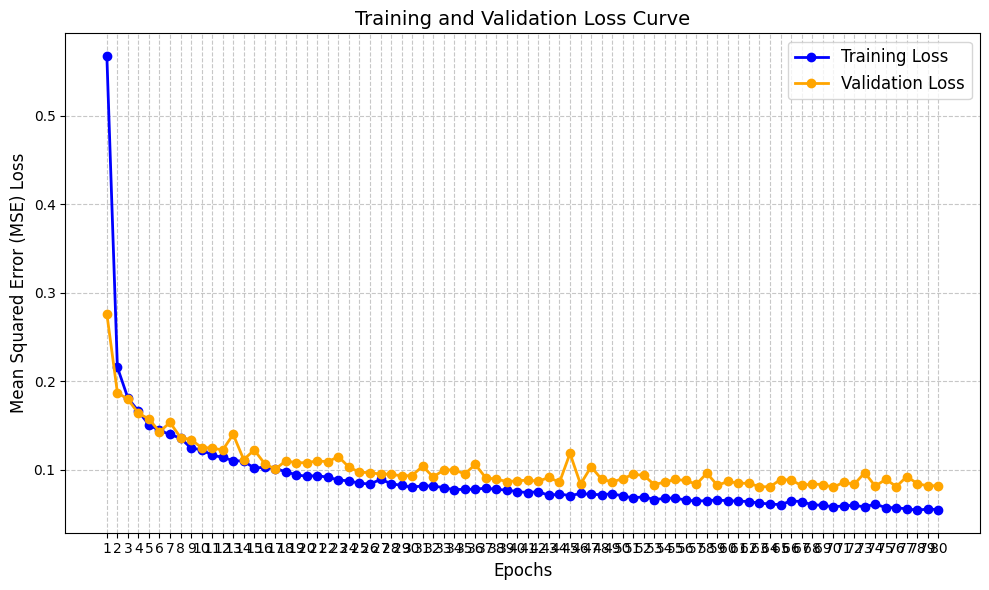

In [24]:
#device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device = 'cpu'
model = GNNEncoder(in_channels=3, hidden_channels=64, out_channels=2, k=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, optimizer, epochs=100, device='cpu')
plot_train(train_losses, val_losses)

In [25]:
def denormalize(norm, mean, std):
    return norm * std + mean
    
def evaluate_model(model, test_loader, x_mean, x_std, y_mean, y_std):
    model.eval()
    mse_loss = 0
    mae_loss = 0
    preds = []
    trues = []
    
    with torch.no_grad():
        for data, labels in test_loader:
            # We predict using the normalized input data
            out = model(data)
            
            # Accumulate sum of squared errors and absolute errors on normalized labels
            mse_loss += F.mse_loss(out, labels, reduction='sum').item()
            
            
            preds.append(out.cpu().numpy())
            trues.append(labels.cpu().numpy())
            
    # Concatenate all batches
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    
    # Calculate global metrics (Normalized space)
    mse = mse_loss / len(preds)
   
    print(f"Validation MSE (normalized): {mse:.4f}")
   
    
    # --- Denormalize predictions and true values for plotting ---
    preds_denorm = np.zeros_like(preds)
    trues_denorm = np.zeros_like(trues)
    
    preds_denorm[:, 0] = denormalize(preds[:, 0], x_mean, x_std)
    preds_denorm[:, 1] = denormalize(preds[:, 1], y_mean, y_std)
    
    trues_denorm[:, 0] = denormalize(trues[:, 0], x_mean, x_std)
    trues_denorm[:, 1] = denormalize(trues[:, 1], y_mean, y_std)
    
    # Calculate and print metrics in the original/denormalized space
    mse_denorm = np.mean((preds_denorm - trues_denorm)**2)
  
 
    # --- Visualization: True vs Predicted scatter plots (DENORMALIZED) ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # X position plot
    axes[0].scatter(trues_denorm[:, 0], preds_denorm[:, 0], alpha=0.5, color='blue')
    min_x, max_x = trues_denorm[:, 0].min(), trues_denorm[:, 0].max()
    axes[0].plot([min_x, max_x], [min_x, max_x], 'r--')  # Ideal prediction line
    axes[0].set_xlabel('True X Position')
    axes[0].set_ylabel('Predicted X Position')
    axes[0].set_title('X Position: True vs Predicted')
    
    # Y position plot
    axes[1].scatter(trues_denorm[:, 1], preds_denorm[:, 1], alpha=0.5, color='green')
    min_y, max_y = trues_denorm[:, 1].min(), trues_denorm[:, 1].max()
    axes[1].plot([min_y, max_y], [min_y, max_y], 'r--')  # Ideal prediction line
    axes[1].set_xlabel('True Y Position')
    axes[1].set_ylabel('Predicted Y Position')
    axes[1].set_title('Y Position: True vs Predicted')
    
    plt.tight_layout()
    plt.show()
    
    return preds_denorm, trues_denorm


Validation MSE (normalized): 0.1525


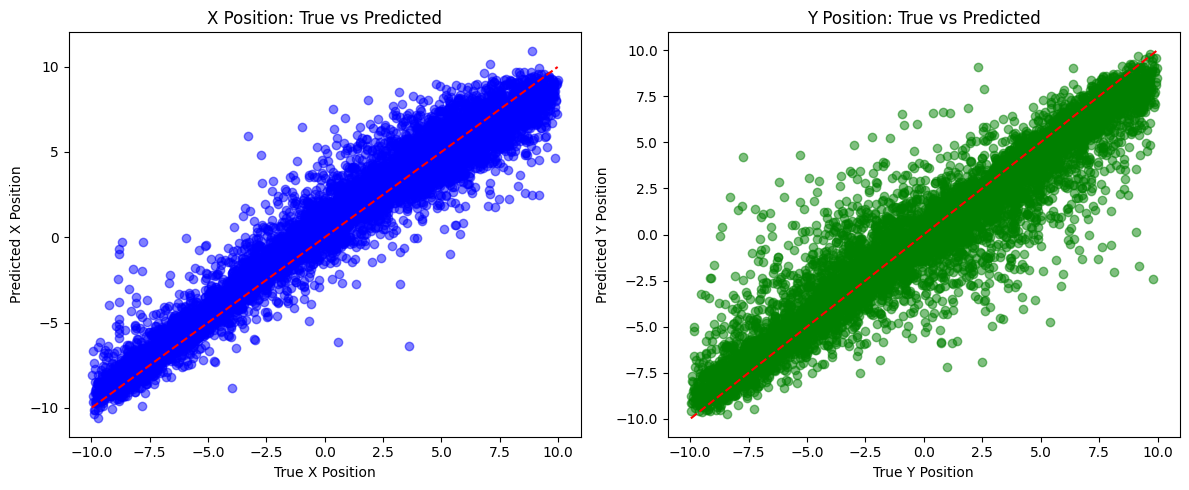

In [26]:
model.load_state_dict(best_model) 

# To execute the evaluation simply call:
all_predictions, all_trues = evaluate_model(model, test_loader, x_mean, x_std, y_mean, y_std)


In [27]:
all_pred_x = all_predictions[:,0]
all_pred_y = all_predictions[:,1]

all_true_x = all_trues[:,0]
all_true_y = all_trues[:,1]

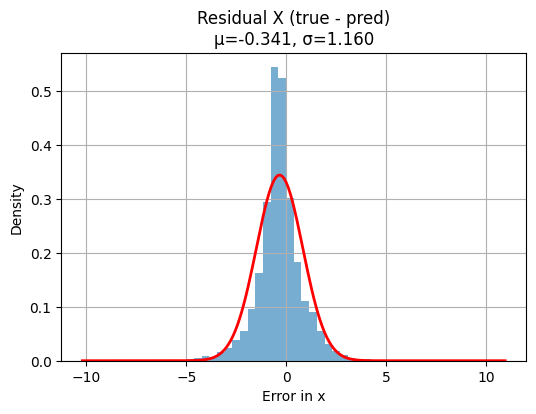

In [28]:
from scipy.stats import norm

res_x = all_true_x - all_pred_x

mu, sigma = norm.fit(res_x)

plt.figure(figsize=(6,4))

# histograma normalizado
plt.hist(res_x, bins=50, density=True, alpha=0.6)

# curva gaussiana ajustada
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, 'r', linewidth=2)

plt.title(f"Residual X (true - pred)\nμ={mu:.3f}, σ={sigma:.3f}")
plt.xlabel("Error in x")
plt.ylabel("Density")
plt.grid(True)

plt.show()

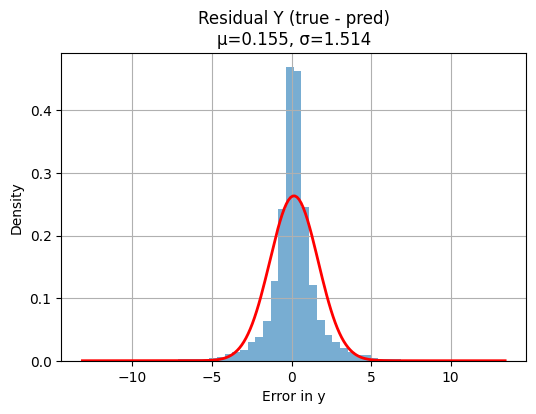

In [29]:
res_y = all_true_y - all_pred_y

mu, sigma = norm.fit(res_y)

plt.figure(figsize=(6,4))

plt.hist(res_y, bins=50, density=True, alpha=0.6)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, mu, sigma)

plt.plot(x, p, 'r', linewidth=2)

plt.title(f"Residual Y (true - pred)\nμ={mu:.3f}, σ={sigma:.3f}")
plt.xlabel("Error in y")
plt.ylabel("Density")
plt.grid(True)

plt.show()

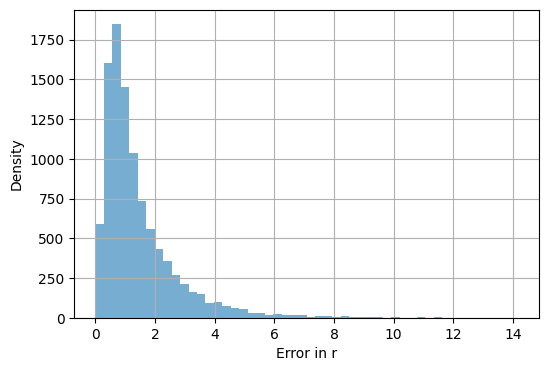

In [30]:
res_r = np.sqrt((all_true_x - all_pred_x)**2 +
                (all_true_y - all_pred_y)**2)

plt.figure(figsize=(6,4))

plt.hist(res_r, bins=50, alpha=0.6)
plt.xlabel("Error in r")
plt.ylabel("Density")
plt.grid(True)

plt.show()

In [31]:
mean_error = np.mean(res_r)
print('mean error r', mean_error)

mean error r 1.444239
